Using device: cuda
Original dataset shape: (692703, 79)

Number of columns: 79
First 10 columns: ['Destination Port', 'Flow Duration', 'Total Fwd Packets', 'Total Backward Packets', 'Total Length of Fwd Packets', 'Total Length of Bwd Packets', 'Fwd Packet Length Max', 'Fwd Packet Length Min', 'Fwd Packet Length Mean', 'Fwd Packet Length Std']

Class distribution before filtering:
 Label
BENIGN              440031
DoS Hulk            231073
DoS GoldenEye        10293
DoS slowloris         5796
DoS Slowhttptest      5499
Heartbleed              11
Name: count, dtype: int64


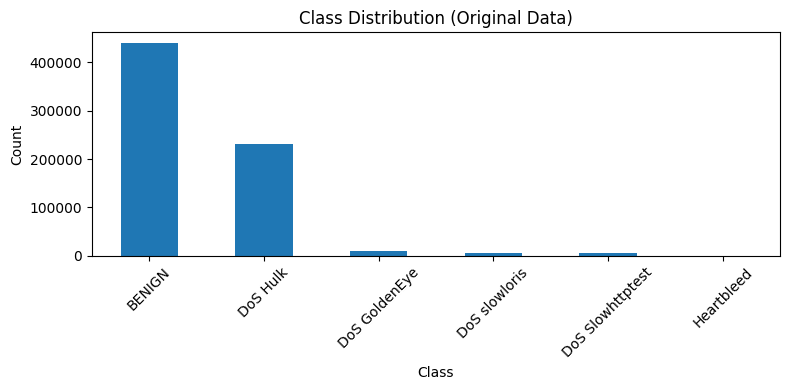


Filtered dataset shape: (692692, 79)

Class distribution after filtering:
 Label
BENIGN              440031
DoS Hulk            231073
DoS GoldenEye        10293
DoS slowloris         5796
DoS Slowhttptest      5499
Name: count, dtype: int64


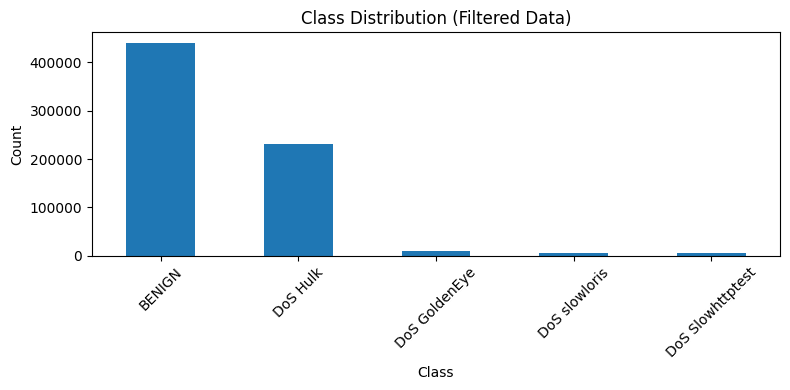


Feature matrix shape after cleaning: (691395, 78)
Final training shape: (20000, 78)
Number of features used: 78
Epoch [1/100] | D Loss: 1.3417 | G Loss: 0.7251
Epoch [10/100] | D Loss: 1.1182 | G Loss: 1.1093
Epoch [20/100] | D Loss: 1.0492 | G Loss: 1.2493
Epoch [30/100] | D Loss: 1.0254 | G Loss: 1.3110
Epoch [40/100] | D Loss: 1.0123 | G Loss: 1.3249
Epoch [50/100] | D Loss: 1.0101 | G Loss: 1.3463
Epoch [60/100] | D Loss: 0.9947 | G Loss: 1.3660
Epoch [70/100] | D Loss: 0.9907 | G Loss: 1.3600
Epoch [80/100] | D Loss: 0.9875 | G Loss: 1.3682
Epoch [90/100] | D Loss: 0.9719 | G Loss: 1.3916
Epoch [100/100] | D Loss: 0.9546 | G Loss: 1.4393


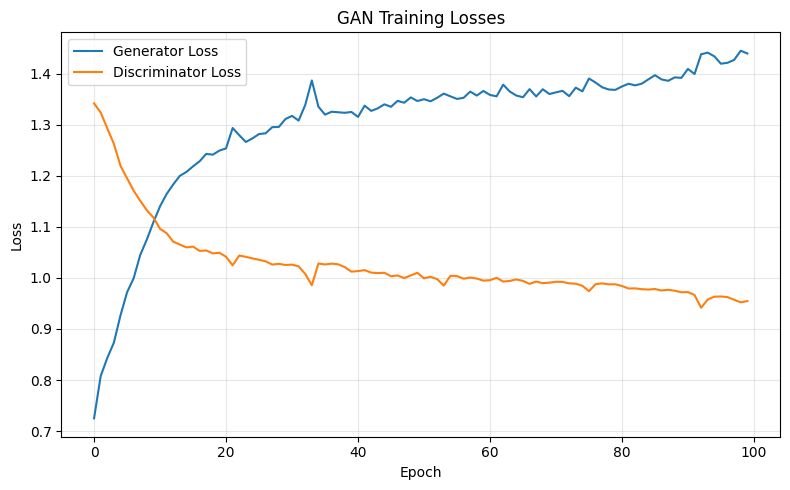


Generated synthetic sample shape: (2000, 78)

First 5 generated rows:
   Destination Port  Flow Duration  Total Fwd Packets  Total Backward Packets  \
0         61.288723  -6.065358e+05           4.551516               -0.666234   
1         43.042141   1.370362e+05          -0.071139               -1.814476   
2       2621.343994  -6.554738e+05          49.621014               15.211331   
3       -193.059418   1.359183e+07          11.253299                5.639391   
4        419.328766   2.049042e+05         -10.436417               -4.202439   

   Total Length of Fwd Packets  Total Length of Bwd Packets  \
0                   199.445724                 -4028.581055   
1                    89.547165                -14767.784180   
2                  3345.058838                  4983.802734   
3                   974.342041                 24133.058594   
4                   290.670105                 14879.623047   

   Fwd Packet Length Max  Fwd Packet Length Min  Fwd Packet Len

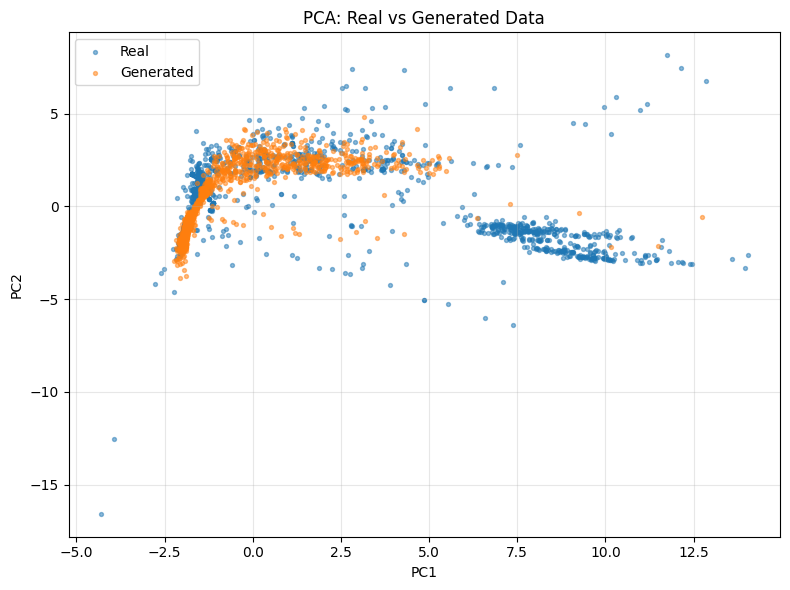


Average absolute difference in scaled feature means: 0.2052
Average absolute difference in scaled feature stds : 0.5210


In [ ]:
import os
import random
import numpy as np
import pandas as pd
import torch
from torch import nn
from torch.utils.data import DataLoader, TensorDataset
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

torch.manual_seed(42)
np.random.seed(42)
random.seed(42)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

FILE_PATH = "Wednesday-workingHours.pcap_ISCX.csv"

BATCH_SIZE = 128
LATENT_DIM = 64
NUM_EPOCHS = 100
LR_G = 0.0002
LR_D = 0.00015
BETA1 = 0.5
BETA2 = 0.999
REAL_LABEL = 0.9   # label smoothing
FAKE_LABEL = 0.0
MAX_SAMPLES = 20000

df = pd.read_csv(FILE_PATH)
print("Original dataset shape:", df.shape)

#clean columns
df.columns = df.columns.str.strip()

if "Label" not in df.columns:
    raise ValueError("Could not find 'Label' column in dataset.")

print("\nNumber of columns:", len(df.columns))
print("First 10 columns:", df.columns[:10].tolist())

#check labels
label_counts = df["Label"].value_counts()
print("\nClass distribution before filtering:\n", label_counts)

plt.figure(figsize=(8, 4))
label_counts.plot(kind="bar")
plt.title("Class Distribution (Original Data)")
plt.xlabel("Class")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

#select required classes
selected_classes = [
    "BENIGN",
    "DoS Hulk",
    "DoS GoldenEye",
    "DoS slowloris",
    "DoS Slowhttptest"
]

df_filtered = df[df["Label"].isin(selected_classes)].copy()
print("\nFiltered dataset shape:", df_filtered.shape)

filtered_counts = df_filtered["Label"].value_counts()
print("\nClass distribution after filtering:\n", filtered_counts)

plt.figure(figsize=(8, 4))
filtered_counts.plot(kind="bar")
plt.title("Class Distribution (Filtered Data)")
plt.xlabel("Class")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

#clean features
X = df_filtered.drop(columns=["Label"]).copy()

for col in X.columns:
    X[col] = pd.to_numeric(X[col], errors="coerce")

X = X.replace([np.inf, -np.inf], np.nan).dropna(axis=0)
labels_filtered = df_filtered.loc[X.index, "Label"].reset_index(drop=True)
X = X.reset_index(drop=True)

print("\nFeature matrix shape after cleaning:", X.shape)

#scale data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
if len(X_scaled) > MAX_SAMPLES:
    idx = np.random.choice(len(X_scaled), MAX_SAMPLES, replace=False)
    X_scaled = X_scaled[idx]
    labels_filtered = labels_filtered.iloc[idx].reset_index(drop=True)

print("Final training shape:", X_scaled.shape)

X_tensor = torch.tensor(X_scaled, dtype=torch.float32)
train_dataset = TensorDataset(X_tensor)
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, drop_last=True)

feature_dim = X_tensor.shape[1]
print("Number of features used:", feature_dim)

def plot_losses(g_losses, d_losses):
    plt.figure(figsize=(8, 5))
    plt.plot(g_losses, label="Generator Loss")
    plt.plot(d_losses, label="Discriminator Loss")
    plt.title("GAN Training Losses")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

def plot_pca(real_data, fake_data, n_samples=2000):
    n = min(n_samples, len(real_data), len(fake_data))
    real_subset = real_data[:n]
    fake_subset = fake_data[:n]

    combined = np.vstack([real_subset, fake_subset])
    pca = PCA(n_components=2, random_state=42)
    combined_pca = pca.fit_transform(combined)

    real_pca = combined_pca[:n]
    fake_pca = combined_pca[n:]

    plt.figure(figsize=(8, 6))
    plt.scatter(real_pca[:, 0], real_pca[:, 1], s=8, alpha=0.5, label="Real")
    plt.scatter(fake_pca[:, 0], fake_pca[:, 1], s=8, alpha=0.5, label="Generated")
    plt.title("PCA: Real vs Generated Data")
    plt.xlabel("PC1")
    plt.ylabel("PC2")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

#define GAN models
class Generator(nn.Module):
    def __init__(self, latent_dim, output_dim):
        super().__init__()
        self.model = nn.Sequential(
            nn.Linear(latent_dim, 128),
            nn.BatchNorm1d(128),
            nn.LeakyReLU(0.2),

            nn.Linear(128, 256),
            nn.BatchNorm1d(256),
            nn.LeakyReLU(0.2),

            nn.Linear(256, output_dim)
        )

    def forward(self, z):
        return self.model(z)

class Discriminator(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.model = nn.Sequential(
            nn.Linear(input_dim, 256),
            nn.LeakyReLU(0.2),
            nn.Dropout(0.25),

            nn.Linear(256, 128),
            nn.LeakyReLU(0.2),
            nn.Dropout(0.25),

            nn.Linear(128, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.model(x)

generator = Generator(LATENT_DIM, feature_dim).to(device)
discriminator = Discriminator(feature_dim).to(device)

criterion = nn.BCELoss()
optimizer_g = torch.optim.Adam(generator.parameters(), lr=LR_G, betas=(BETA1, BETA2))
optimizer_d = torch.optim.Adam(discriminator.parameters(), lr=LR_D, betas=(BETA1, BETA2))

#Train GAN
g_losses = []
d_losses = []

for epoch in range(NUM_EPOCHS):
    epoch_g_loss = 0.0
    epoch_d_loss = 0.0

    for (real_batch,) in train_loader:
        real_batch = real_batch.to(device)
        batch_size = real_batch.size(0)

        real_targets = torch.full((batch_size, 1), REAL_LABEL, device=device)
        fake_targets = torch.full((batch_size, 1), FAKE_LABEL, device=device)

        #discriminator
        optimizer_d.zero_grad()

        real_preds = discriminator(real_batch)
        loss_real = criterion(real_preds, real_targets)

        noise = torch.randn(batch_size, LATENT_DIM, device=device)
        fake_batch = generator(noise)

        fake_preds = discriminator(fake_batch.detach())
        loss_fake = criterion(fake_preds, fake_targets)

        d_loss = loss_real + loss_fake
        d_loss.backward()
        optimizer_d.step()

        #generator
        optimizer_g.zero_grad()

        noise = torch.randn(batch_size, LATENT_DIM, device=device)
        generated_batch = generator(noise)
        gen_preds = discriminator(generated_batch)

        g_loss = criterion(gen_preds, real_targets)
        g_loss.backward()
        optimizer_g.step()

        epoch_d_loss += d_loss.item()
        epoch_g_loss += g_loss.item()

    avg_d_loss = epoch_d_loss / len(train_loader)
    avg_g_loss = epoch_g_loss / len(train_loader)

    d_losses.append(avg_d_loss)
    g_losses.append(avg_g_loss)

    if (epoch + 1) % 10 == 0 or epoch == 0:
        print(f"Epoch [{epoch+1}/{NUM_EPOCHS}] | D Loss: {avg_d_loss:.4f} | G Loss: {avg_g_loss:.4f}")

plot_losses(g_losses, d_losses)

#synthetic samples
generator.eval()
num_samples = min(2000, len(X_scaled))

with torch.no_grad():
    noise = torch.randn(num_samples, LATENT_DIM, device=device)
    generated_scaled = generator(noise).cpu().numpy()

#converting back to original scale
generated_original = scaler.inverse_transform(generated_scaled)
generated_df = pd.DataFrame(generated_original, columns=X.columns)

print("\nGenerated synthetic sample shape:", generated_df.shape)
print("\nFirst 5 generated rows:")
print(generated_df.head())

#PCA for real vs fake
plot_pca(X_scaled, generated_scaled, n_samples=num_samples)

#numjeric comparision
real_means = X_scaled.mean(axis=0)
fake_means = generated_scaled.mean(axis=0)

real_stds = X_scaled.std(axis=0)
fake_stds = generated_scaled.std(axis=0)

mean_diff = np.mean(np.abs(real_means - fake_means))
std_diff = np.mean(np.abs(real_stds - fake_stds))

print(f"\nAverage absolute difference in scaled feature means: {mean_diff:.4f}")
print(f"Average absolute difference in scaled feature stds : {std_diff:.4f}")